# Comparative Evaluation of Preprocessing Choices

### Machine Learning Classification on Clinical Diabetes Data

---

1. **Dataset:** Pima Indians Diabetes Dataset
2. **Task:** Binary Classification
3. **Target Variable:** `Outcome`
4. **Baseline Model:** Logistic Regression
5. **Environment:** Python · Google Colab · Scikit-learn · Imbalanced-learn

---

## Project Overview

This Task investigates how different **preprocessing and class-imbalance strategies** affect the performance of a machine learning classifier on clinical diabetes data.

The study uses a controlled experimental framework in which multiple preprocessing configurations are evaluated using the same:

* Dataset
* Train-test split
* Random state
* Classification algorithm
* Evaluation procedure

This ensures that performance differences can be primarily attributed to the preprocessing and imbalance-handling strategies rather than changes in the modeling setup.

### Preprocessing Strategies Evaluated

1. **Median Imputation** handling clinically invalid zero values as missing observations.
2. **Feature Scaling**  evaluating the effect of `StandardScaler` on Logistic Regression.
3. **SMOTE**  addressing class imbalance through synthetic minority-class samples.
4. **Class Weighting**  giving greater importance to the minority diabetic class.
5. **Threshold Adjustment**  analyzing the trade-off between precision and recall.

### Evaluation Framework

Model performance is assessed using:

* Accuracy
* Precision
* Recall
* F1-score
* Confusion Matrix
* False-Positive Rate (FPR)
* False-Negative Rate (FNR)
* ROC-AUC
* PR-AUC
* Classification Threshold Analysis

Because this is a clinical classification problem, particular attention is given to **diabetic-class recall, F1-score, and false-negative reduction**, rather than relying on accuracy alone.

### Experimental Goal

The primary goal is to determine which preprocessing configuration provides the most appropriate balance between:

**Overall Performance → Minority-Class Detection → False-Negative Reduction**

The project also examines the predictive influence of clinical features in the selected Logistic Regression model and discusses the limitations of using a benchmark dataset for clinical prediction.



## 1 Import Libraries

In [2]:
# ============================================
# Step 1: Dataset Understanding
# Pima Indians Diabetes Dataset
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Load Dataset

In [3]:
# Load dataset
df = pd.read_csv("/content/diabetes.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


### Dataset Shape

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 768
Number of columns: 9
Dataset shape: (768, 9)


### First 5 Records

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Column Names

In [6]:
print("Columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns:
1. Pregnancies
2. Glucose
3. BloodPressure
4. SkinThickness
5. Insulin
6. BMI
7. DiabetesPedigreeFunction
8. Age
9. Outcome


### Data Types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Statistical Summary

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Missing Values

In [9]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

missing_summary

,Missing Values,Missing Percentage
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


### Duplicate Records

In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Target Distribution

In [11]:
target_counts = df["Outcome"].value_counts().sort_index()

print("Target distribution:")
print(target_counts)

print("\nTarget percentage:")
print((target_counts / len(df) * 100).round(2))

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Target percentage:
Outcome
0    65.1
1    34.9
Name: count, dtype: float64


### Target Visualization

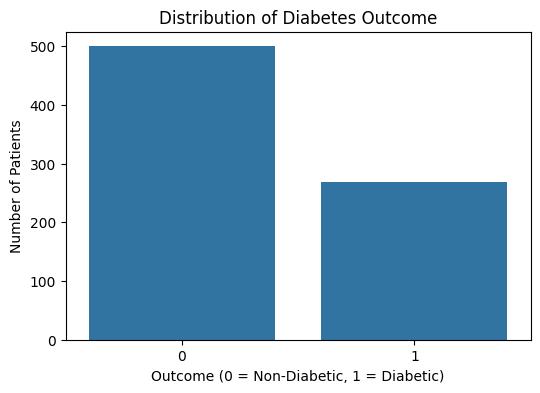

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Outcome")

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")

plt.show()

### Identify Zero Values

This is important for this dataset. We are only identifying the issue now; we are not replacing anything yet.

In [13]:
zero_counts = (df == 0).sum()

zero_summary = pd.DataFrame({
    "Zero Values": zero_counts,
    "Zero Percentage": (zero_counts / len(df)) * 100
})

zero_summary

,Zero Values,Zero Percentage
Pregnancies,111,14.453125
Glucose,5,0.651042
BloodPressure,35,4.557292
SkinThickness,227,29.557292
Insulin,374,48.697917
BMI,11,1.432292
DiabetesPedigreeFunction,0,0.000000
Age,0,0.000000
Outcome,500,65.104167


### Clinical Data Quality Check

In [14]:
clinical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_clinical = (df[clinical_columns] == 0).sum()

clinical_zero_summary = pd.DataFrame({
    "Zero Values": zero_clinical,
    "Zero Percentage": (zero_clinical / len(df)) * 100
})

clinical_zero_summary

,Zero Values,Zero Percentage
Glucose,5,0.651042
BloodPressure,35,4.557292
SkinThickness,227,29.557292
Insulin,374,48.697917
BMI,11,1.432292


### Correlation Overview

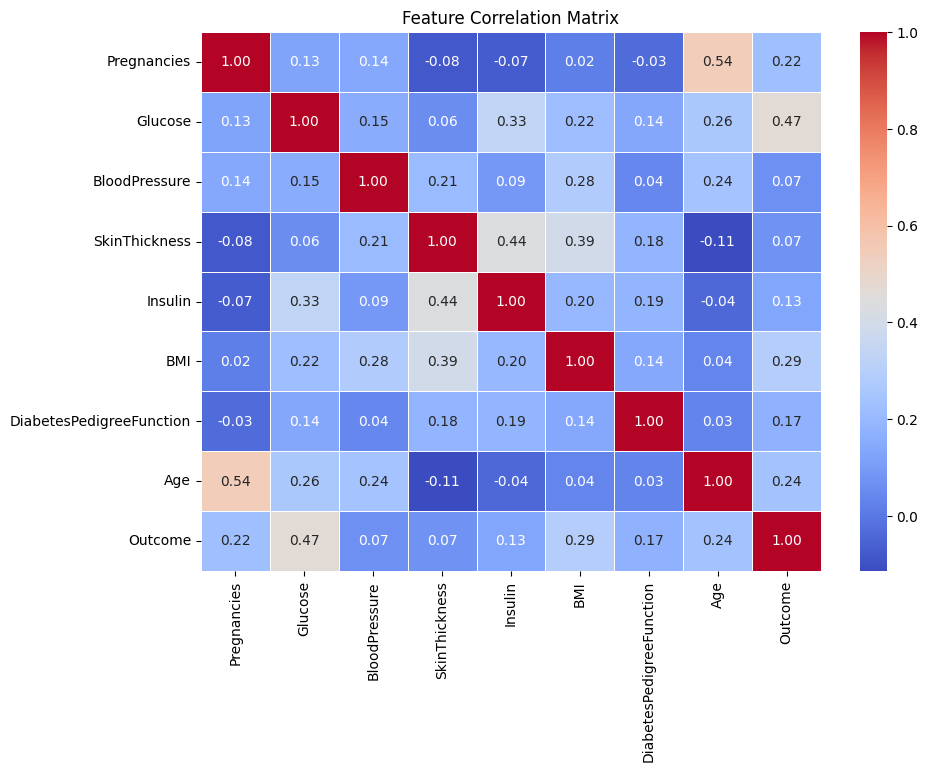

In [15]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.show()

### Final Dataset Overview

In [16]:
print("========== DATASET OVERVIEW ==========")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Target variable: Outcome")
print(f"Class 0: {(df['Outcome'] == 0).sum()}")
print(f"Class 1: {(df['Outcome'] == 1).sum()}")
print("======================================")

========== DATASET OVERVIEW ==========
Rows: 768
Columns: 9
Duplicate rows: 0
Missing values: 0
Target variable: Outcome
Class 0: 500
Class 1: 268


# Step 2: Data Quality & Preprocessing Strategy

In [17]:
# ============================================
# Step 2: Data Quality & Preprocessing Strategy
# ============================================

target = "Outcome"

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

Feature shape: (768, 8)
Target shape: (768,)

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
Outcome


### Identify Invalid Zero Values

In [18]:
# Columns where zero can represent missing/invalid information
zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_summary = pd.DataFrame({
    "Zero Count": (df[zero_as_missing] == 0).sum(),
    "Zero Percentage": (
        (df[zero_as_missing] == 0).sum() / len(df) * 100
    ).round(2)
})

zero_summary

,Zero Count,Zero Percentage
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


### Convert Invalid Zeros to NaN

In [19]:
# Create a working copy
df_clean = df.copy()

# Replace medically invalid zeros with NaN
df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(0, np.nan)

print("Invalid zeros converted to NaN.")

Invalid zeros converted to NaN.


### Check Missing Values After Conversion

In [20]:
missing_summary = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": (
        df_clean.isnull().sum() / len(df_clean) * 100
    ).round(2)
})

missing_summary

,Missing Values,Missing Percentage
Pregnancies,0,0.00
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43
DiabetesPedigreeFunction,0,0.00
Age,0,0.00
Outcome,0,0.00


### Visualize Missing Values

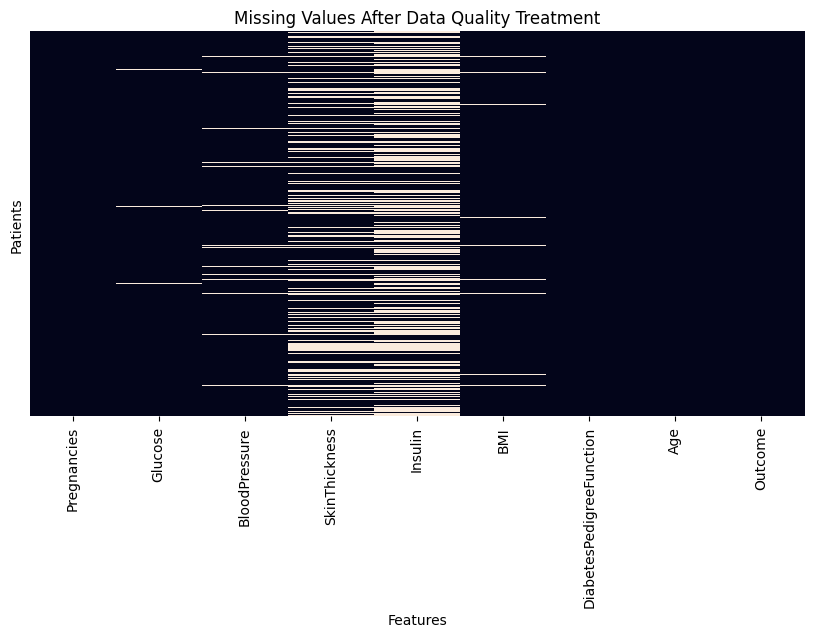

In [21]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    df_clean.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values After Data Quality Treatment")
plt.xlabel("Features")
plt.ylabel("Patients")

plt.show()

### Check Class Imbalance

In [22]:
class_distribution = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percentage": (
        y.value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

class_distribution

,Count,Percentage
Outcome,,
0,500,65.1
1,268,34.9


### Calculate Imbalance Ratio

In [23]:
class_counts = y.value_counts()

majority_class = class_counts.max()
minority_class = class_counts.min()

imbalance_ratio = majority_class / minority_class

print("Majority class:", majority_class)
print("Minority class:", minority_class)
print("Imbalance ratio:", round(imbalance_ratio, 2))

Majority class: 500
Minority class: 268
Imbalance ratio: 1.87


# Step 3  Experimental Setup

### Import ML Libraries

In [24]:
# ============================================
# Step 3: Experimental Setup
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [25]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

### Prepare X and y

In [26]:
# Features and target
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


### Train/Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


### Verify Stratification

In [28]:
print("Training class distribution:")
print(y_train.value_counts().sort_index())

print("\nTraining class percentage:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

print("\nTesting class percentage:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

Training class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Training class percentage:
Outcome
0    65.15
1    34.85
Name: proportion, dtype: float64

Testing class distribution:
Outcome
0    100
1     54
Name: count, dtype: int64

Testing class percentage:
Outcome
0    64.94
1    35.06
Name: proportion, dtype: float64


### Define Invalid-Zero Columns

In [29]:
zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

In [30]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train[zero_as_missing] = X_train[zero_as_missing].replace(0, np.nan)
X_test[zero_as_missing] = X_test[zero_as_missing].replace(0, np.nan)

print("Invalid zeros converted to NaN.")

Invalid zeros converted to NaN.


### Define Evaluation Metrics

In [31]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

print("Evaluation metrics:")
for metric in metrics:
    print("-", metric)

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1 Score


### Define Baseline Model

Our baseline classifier will be Logistic Regression.

In [32]:
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

print(baseline_model)

LogisticRegression(max_iter=1000, random_state=42)


### Why Logistic Regression?

Because this experiment specifically investigates preprocessing choices.

Logistic Regression is useful here because:

1. Feature scaling can affect optimization.
2. Class weighting can directly affect learning.
3. It provides a consistent baseline.
4. It is appropriate for binary classification.
5. Results are easier to compare across preprocessing configurations.

### Baseline Pipeline

Our baseline will use median imputation only.

In [33]:
baseline_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

In [34]:
baseline_pipeline.fit(X_train, y_train)

y_pred_baseline = baseline_pipeline.predict(X_test)

### Evaluate Baseline

In [35]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print("===== BASELINE RESULTS =====")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

===== BASELINE RESULTS =====
Accuracy : 0.7013
Precision: 0.5870
Recall   : 0.5000
F1 Score : 0.5400


### Baseline Classification Report

In [36]:
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["Non-Diabetic", "Diabetic"]
))

              precision    recall  f1-score   support

Non-Diabetic       0.75      0.81      0.78       100
    Diabetic       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



### Baseline Confusion Matrix

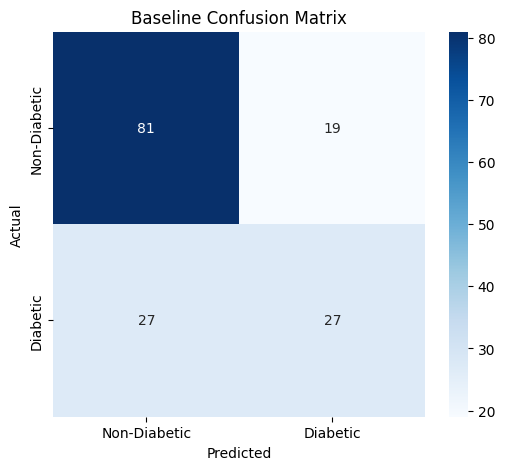

In [37]:
cm = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 3. Experimental Setup

The dataset is divided into training and testing subsets using an 80:20
split with stratified sampling. Stratification is used to preserve the
proportion of diabetic and non-diabetic cases in both subsets.

A fixed random state of 42 is used to ensure reproducibility across all
experiments.

Logistic Regression is selected as the baseline classifier because it is
sensitive to feature scaling and allows the effects of different
preprocessing strategies to be evaluated clearly.

The evaluation uses Accuracy, Precision, Recall, and F1 Score. Because this
is a clinical classification problem, particular attention will be given
to Recall and F1 Score for the diabetic class.

Invalid zero values in Glucose, BloodPressure, SkinThickness, Insulin, and
BMI are treated as missing values. Median imputation is performed through a
pipeline so that the imputation statistics are learned only from the
training data.

The same train/test split, classifier, random state, and evaluation metrics
will be maintained across all preprocessing experiments. Only the
preprocessing or imbalance-handling strategy will change.

This controlled experimental design allows the downstream effect of
preprocessing choices to be compared fairly.

## Baseline Results Interpretation

The stratified 80:20 train-test split produced 614 training samples and
154 testing samples while preserving the original class distribution.

The baseline Logistic Regression model achieved an accuracy of 70.13%,
precision of 58.70%, recall of 50.00%, and F1 Score of 54.00%.

The model performed better for the non-diabetic class than for the
diabetic class. The recall for the diabetic class was only 50%, indicating
that approximately half of the actual diabetic cases in the test set were
not correctly identified by the baseline model.

This result establishes the baseline performance for the preprocessing
experiments. Subsequent experiments will investigate whether feature
scaling, SMOTE, and class weighting can improve minority-class
performance without substantially reducing overall predictive
performance.

The baseline model will remain unchanged during the comparative
experiments so that improvements can be attributed to preprocessing and
imbalance-handling strategies rather than changes in the underlying
classifier.

#Step 4 Preprocessing Experiments

### Median Imputation + Standard Scaling



In this experiment, the baseline preprocessing is extended by applying
StandardScaler after median imputation.

Standardization transforms numerical features so that they have a mean
close to zero and a standard deviation close to one.

This is particularly important for Logistic Regression because features
with larger numerical ranges can disproportionately influence the model.

The imputer and scaler are placed inside a pipeline to ensure that their
parameters are learned only from the training data.

In [38]:
# Median Imputation + Standard Scaling

e1_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

# Train
e1_pipeline.fit(X_train, y_train)

# Predict
y_pred_e1 = e1_pipeline.predict(X_test)

# Evaluation
e1_accuracy = accuracy_score(y_test, y_pred_e1)
e1_precision = precision_score(y_test, y_pred_e1)
e1_recall = recall_score(y_test, y_pred_e1)
e1_f1 = f1_score(y_test, y_pred_e1)

print("E1 - Standard Scaling")
print(f"Accuracy : {e1_accuracy:.4f}")
print(f"Precision: {e1_precision:.4f}")
print(f"Recall   : {e1_recall:.4f}")
print(f"F1 Score : {e1_f1:.4f}")

E1 - Standard Scaling
Accuracy : 0.7078
Precision: 0.6000
Recall   : 0.5000
F1 Score : 0.5455


In [39]:
print("\nClassification Report - E1")
print(classification_report(
    y_test,
    y_pred_e1,
    target_names=["Non-Diabetic", "Diabetic"]
))


Classification Report - E1
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



### E2  Standard Scaling + SMOTE

## Experiment E2  Standard Scaling + SMOTE

This experiment introduces Synthetic Minority Over-sampling Technique
(SMOTE) to address class imbalance.

SMOTE generates synthetic minority-class observations using neighboring
training samples.

The preprocessing order is:

1. Median imputation
2. Standard scaling
3. SMOTE
4. Logistic Regression

SMOTE is applied only to the training data through an imbalanced-learn
pipeline. The test set remains completely untouched so that evaluation
represents the model's performance on the original data distribution.

In [40]:
# E2: Median Imputation + Standard Scaling + SMOTE

e2_pipeline = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

# Train
e2_pipeline.fit(X_train, y_train)

# Predict on original test data
y_pred_e2 = e2_pipeline.predict(X_test)

# Evaluation
e2_accuracy = accuracy_score(y_test, y_pred_e2)
e2_precision = precision_score(y_test, y_pred_e2)
e2_recall = recall_score(y_test, y_pred_e2)
e2_f1 = f1_score(y_test, y_pred_e2)

print("E2 - SMOTE")
print(f"Accuracy : {e2_accuracy:.4f}")
print(f"Precision: {e2_precision:.4f}")
print(f"Recall   : {e2_recall:.4f}")
print(f"F1 Score : {e2_f1:.4f}")

E2 - SMOTE
Accuracy : 0.7078
Precision: 0.5738
Recall   : 0.6481
F1 Score : 0.6087


In [41]:
print("\nClassification Report - E2")
print(classification_report(
    y_test,
    y_pred_e2,
    target_names=["Non-Diabetic", "Diabetic"]
))


Classification Report - E2
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.74      0.77       100
    Diabetic       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154



### Standard Scaling + Class Weight

## Experiment E3 Standard Scaling + Class Weight

This experiment addresses class imbalance using class weighting instead of
synthetic oversampling.

The Logistic Regression model is configured with
class_weight="balanced", which automatically assigns greater importance
to the minority class.

Unlike SMOTE, this approach does not create additional synthetic
observations.

The preprocessing pipeline consists of:

1. Median imputation
2. Standard scaling
3. Class-weighted Logistic Regression

This experiment allows comparison between data-level imbalance handling
(SMOTE) and algorithm-level imbalance handling (class weighting).

In [42]:
# E3: Median Imputation + Standard Scaling + Class Weight

e3_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

# Train
e3_pipeline.fit(X_train, y_train)

# Predict
y_pred_e3 = e3_pipeline.predict(X_test)

# Evaluation
e3_accuracy = accuracy_score(y_test, y_pred_e3)
e3_precision = precision_score(y_test, y_pred_e3)
e3_recall = recall_score(y_test, y_pred_e3)
e3_f1 = f1_score(y_test, y_pred_e3)

print("E3 - Class Weight")
print(f"Accuracy : {e3_accuracy:.4f}")
print(f"Precision: {e3_precision:.4f}")
print(f"Recall   : {e3_recall:.4f}")
print(f"F1 Score : {e3_f1:.4f}")

E3 - Class Weight
Accuracy : 0.7338
Precision: 0.6032
Recall   : 0.7037
F1 Score : 0.6496


In [43]:
print("\nClassification Report - E3")
print(classification_report(
    y_test,
    y_pred_e3,
    target_names=["Non-Diabetic", "Diabetic"]
))


Classification Report - E3
              precision    recall  f1-score   support

Non-Diabetic       0.82      0.75      0.79       100
    Diabetic       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



### Create Experimental Comparison Table

In [44]:
results = pd.DataFrame({
    "Experiment": [
        "E0 - Baseline",
        "E1 - Scaling",
        "E2 - SMOTE",
        "E3 - Class Weight"
    ],
    "Accuracy": [
        0.7013,
        e1_accuracy,
        e2_accuracy,
        e3_accuracy
    ],
    "Precision": [
        0.5870,
        e1_precision,
        e2_precision,
        e3_precision
    ],
    "Recall": [
        0.5000,
        e1_recall,
        e2_recall,
        e3_recall
    ],
    "F1 Score": [
        0.5400,
        e1_f1,
        e2_f1,
        e3_f1
    ]
})

results

,Experiment,Accuracy,Precision,Recall,F1 Score
0,E0 - Baseline,0.701300,0.587000,0.500000,0.540000
1,E1 - Scaling,0.707792,0.600000,0.500000,0.545455
2,E2 - SMOTE,0.707792,0.573770,0.648148,0.608696
3,E3 - Class Weight,0.733766,0.603175,0.703704,0.649573


In [45]:
results_display = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    results_display[column] = (
        results_display[column] * 100
    ).round(2)

results_display

,Experiment,Accuracy,Precision,Recall,F1 Score
0,E0 - Baseline,70.13,58.70,50.00,54.00
1,E1 - Scaling,70.78,60.00,50.00,54.55
2,E2 - SMOTE,70.78,57.38,64.81,60.87
3,E3 - Class Weight,73.38,60.32,70.37,64.96


### Visual Comparison

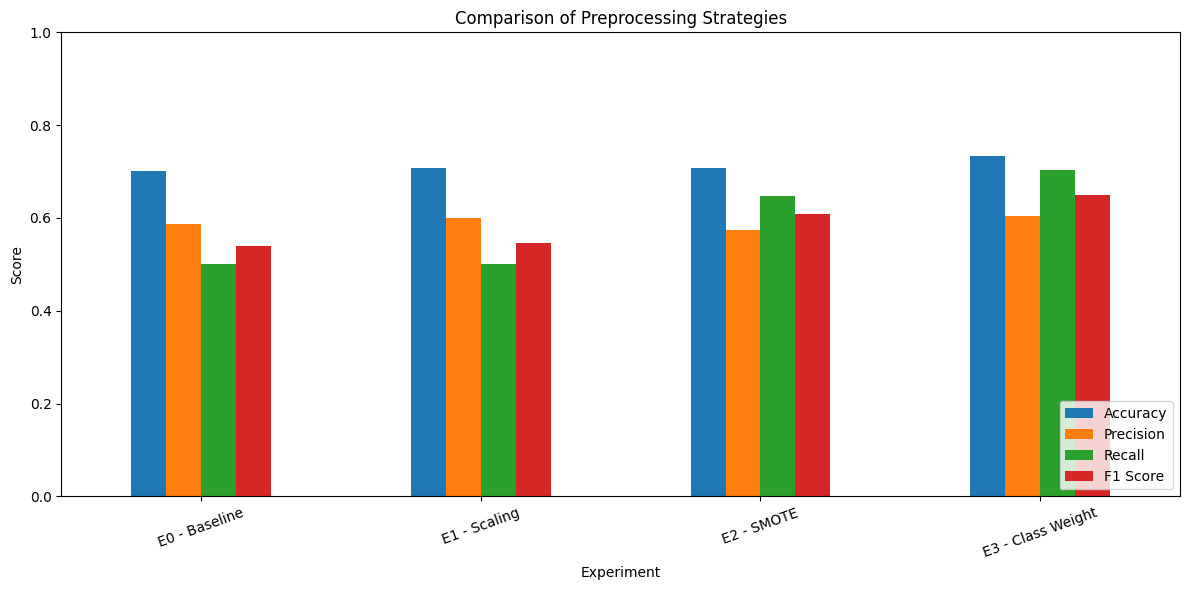

In [46]:
results_plot = results.set_index("Experiment")

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Preprocessing Strategies")
plt.ylabel("Score")
plt.xlabel("Experiment")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

###Preprocessing Experiment Summary

Four preprocessing configurations are evaluated using Logistic Regression.

E0 represents the baseline model using median imputation without scaling or
imbalance handling.

E1 adds StandardScaler to investigate the effect of feature normalization.

E2 introduces SMOTE after imputation and scaling to address class imbalance
through synthetic minority-class samples.

E3 uses class-weighted Logistic Regression as an alternative approach to
handling class imbalance without generating synthetic observations.

All experiments use the same training and testing split, random state,
classifier family, and evaluation metrics. Therefore, differences in
performance can be attributed primarily to the preprocessing strategy.

The diabetic class is treated as the positive class. Recall and F1 Score
are particularly important because a clinical model should minimize the
number of diabetic cases that are incorrectly classified as non-diabetic.

The numerical results will be analyzed in the next stage to determine
which preprocessing configuration provides the most appropriate balance
between predictive performance and clinical relevance.

## Initial Findings from Preprocessing Experiments

The preprocessing experiments demonstrate that different preprocessing
strategies have different effects on downstream Logistic Regression
performance.

Standard scaling alone produced only a small improvement over the baseline,
with accuracy increasing from 70.13% to 70.78% while diabetic-class recall
remained unchanged at 50.00%.

SMOTE substantially improved diabetic-class recall from 50.00% to 64.81%
and increased the diabetic-class F1 score from 54.00% to 60.87%. However,
precision decreased from 60.00% in the scaling experiment to 57.38%.

Class weighting produced the strongest overall results. It achieved 73.38%
accuracy, 60.32% precision, 70.37% recall, and 64.96% F1 score for the
positive diabetic class.

These results suggest that addressing class imbalance has a greater impact
on diabetic-case detection than scaling alone. Class weighting currently
provides the best balance between precision and recall among the tested
configurations.

Further analysis using confusion matrices and class-specific error
analysis is required before selecting the final model.

# Step 5  Comparative Evaluation

### Confusion Matrix Analysis

A confusion matrix provides a detailed view of classification errors.

For this project:

- True Negative (TN): Non-diabetic correctly classified as non-diabetic
- False Positive (FP): Non-diabetic incorrectly classified as diabetic
- False Negative (FN): Diabetic incorrectly classified as non-diabetic
- True Positive (TP): Diabetic correctly classified as diabetic

False Negatives are particularly important in this clinical problem because
they represent diabetic cases that the model fails to detect.

In [47]:
# Generate confusion matrices for all experiments

cm_e0 = confusion_matrix(y_test, y_pred_baseline)
cm_e1 = confusion_matrix(y_test, y_pred_e1)
cm_e2 = confusion_matrix(y_test, y_pred_e2)
cm_e3 = confusion_matrix(y_test, y_pred_e3)

print("E0 - Baseline")
print(cm_e0)

print("\nE1 - Scaling")
print(cm_e1)

print("\nE2 - SMOTE")
print(cm_e2)

print("\nE3 - Class Weight")
print(cm_e3)

E0 - Baseline
[[81 19]
 [27 27]]

E1 - Scaling
[[82 18]
 [27 27]]

E2 - SMOTE
[[74 26]
 [19 35]]

E3 - Class Weight
[[75 25]
 [16 38]]


### Extract TN, FP, FN, TP

In [48]:
def extract_confusion_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    return tn, fp, fn, tp


tn_e0, fp_e0, fn_e0, tp_e0 = extract_confusion_metrics(cm_e0)
tn_e1, fp_e1, fn_e1, tp_e1 = extract_confusion_metrics(cm_e1)
tn_e2, fp_e2, fn_e2, tp_e2 = extract_confusion_metrics(cm_e2)
tn_e3, fp_e3, fn_e3, tp_e3 = extract_confusion_metrics(cm_e3)

confusion_results = pd.DataFrame({
    "Experiment": [
        "E0 - Baseline",
        "E1 - Scaling",
        "E2 - SMOTE",
        "E3 - Class Weight"
    ],
    "TN": [tn_e0, tn_e1, tn_e2, tn_e3],
    "FP": [fp_e0, fp_e1, fp_e2, fp_e3],
    "FN": [fn_e0, fn_e1, fn_e2, fn_e3],
    "TP": [tp_e0, tp_e1, tp_e2, tp_e3]
})

confusion_results

,Experiment,TN,FP,FN,TP
0,E0 - Baseline,81,19,27,27
1,E1 - Scaling,82,18,27,27
2,E2 - SMOTE,74,26,19,35
3,E3 - Class Weight,75,25,16,38


### Calculate Error Rates

For clinical interpretation, the **False Negative Rate (FNR)** is also useful.

**Formula:**

$$
FNR = \frac{FN}{FN + TP}
$$

The FNR represents the proportion of **actual diabetic patients that the model incorrectly classified as non-diabetic**.

In [49]:
confusion_results["False Negative Rate"] = (
    confusion_results["FN"] /
    (confusion_results["FN"] + confusion_results["TP"])
)

confusion_results["False Positive Rate"] = (
    confusion_results["FP"] /
    (confusion_results["FP"] + confusion_results["TN"])
)

confusion_results

,Experiment,TN,FP,FN,TP,False Negative Rate,False Positive Rate
0,E0 - Baseline,81,19,27,27,0.500000,0.19
1,E1 - Scaling,82,18,27,27,0.500000,0.18
2,E2 - SMOTE,74,26,19,35,0.351852,0.26
3,E3 - Class Weight,75,25,16,38,0.296296,0.25


In [50]:
error_display = confusion_results.copy()

error_display["False Negative Rate"] = (
    error_display["False Negative Rate"] * 100
).round(2)

error_display["False Positive Rate"] = (
    error_display["False Positive Rate"] * 100
).round(2)

error_display

,Experiment,TN,FP,FN,TP,False Negative Rate,False Positive Rate
0,E0 - Baseline,81,19,27,27,50.00,19.0
1,E1 - Scaling,82,18,27,27,50.00,18.0
2,E2 - SMOTE,74,26,19,35,35.19,26.0
3,E3 - Class Weight,75,25,16,38,29.63,25.0


### Visualize Confusion Matrices

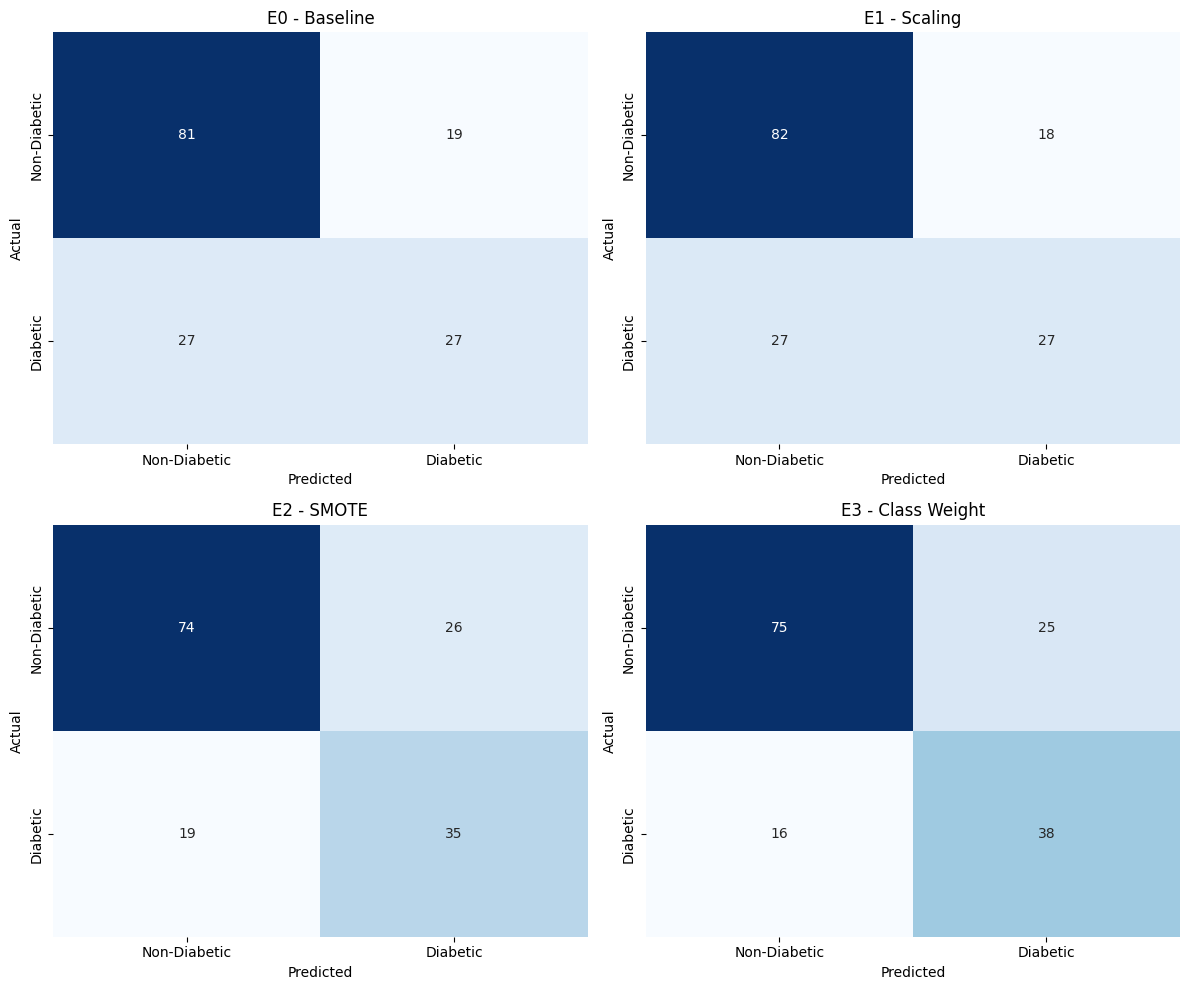

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cms = [
    (cm_e0, "E0 - Baseline"),
    (cm_e1, "E1 - Scaling"),
    (cm_e2, "E2 - SMOTE"),
    (cm_e3, "E3 - Class Weight")
]

for ax, (cm, title) in zip(axes.ravel(), cms):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Non-Diabetic", "Diabetic"],
        yticklabels=["Non-Diabetic", "Diabetic"],
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Compare Diabetic-Class Performance

In [52]:
diabetic_comparison = pd.DataFrame({
    "Experiment": [
        "E0 - Baseline",
        "E1 - Scaling",
        "E2 - SMOTE",
        "E3 - Class Weight"
    ],
    "Diabetic Precision": [
        0.5870,
        e1_precision,
        e2_precision,
        e3_precision
    ],
    "Diabetic Recall": [
        0.5000,
        e1_recall,
        e2_recall,
        e3_recall
    ],
    "Diabetic F1": [
        0.5400,
        e1_f1,
        e2_f1,
        e3_f1
    ]
})

diabetic_comparison

,Experiment,Diabetic Precision,Diabetic Recall,Diabetic F1
0,E0 - Baseline,0.587000,0.500000,0.540000
1,E1 - Scaling,0.600000,0.500000,0.545455
2,E2 - SMOTE,0.573770,0.648148,0.608696
3,E3 - Class Weight,0.603175,0.703704,0.649573


In [53]:
diabetic_display = diabetic_comparison.copy()

for column in [
    "Diabetic Precision",
    "Diabetic Recall",
    "Diabetic F1"
]:
    diabetic_display[column] = (
        diabetic_display[column] * 100
    ).round(2)

diabetic_display

,Experiment,Diabetic Precision,Diabetic Recall,Diabetic F1
0,E0 - Baseline,58.70,50.00,54.00
1,E1 - Scaling,60.00,50.00,54.55
2,E2 - SMOTE,57.38,64.81,60.87
3,E3 - Class Weight,60.32,70.37,64.96


### Calculate Improvement over Baseline

In [54]:
baseline_f1 = 0.5400
baseline_recall = 0.5000

improvement = pd.DataFrame({
    "Experiment": [
        "E1 - Scaling",
        "E2 - SMOTE",
        "E3 - Class Weight"
    ],
    "Recall Improvement": [
        e1_recall - baseline_recall,
        e2_recall - baseline_recall,
        e3_recall - baseline_recall
    ],
    "F1 Improvement": [
        e1_f1 - baseline_f1,
        e2_f1 - baseline_f1,
        e3_f1 - baseline_f1
    ]
})

improvement["Recall Improvement (%)"] = (
    improvement["Recall Improvement"] * 100
).round(2)

improvement["F1 Improvement (%)"] = (
    improvement["F1 Improvement"] * 100
).round(2)

improvement

,Experiment,Recall Improvement,F1 Improvement,Recall Improvement (%),F1 Improvement (%)
0,E1 - Scaling,0.000000,0.005455,0.00,0.55
1,E2 - SMOTE,0.148148,0.068696,14.81,6.87
2,E3 - Class Weight,0.203704,0.109573,20.37,10.96


### Rank the Experiments

In [55]:
ranking = results.copy()

ranking["Rank by Accuracy"] = (
    ranking["Accuracy"]
    .rank(ascending=False, method="min")
    .astype(int)
)

ranking["Rank by Recall"] = (
    ranking["Recall"]
    .rank(ascending=False, method="min")
    .astype(int)
)

ranking["Rank by F1"] = (
    ranking["F1 Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

ranking.sort_values("F1 Score", ascending=False)

,Experiment,Accuracy,Precision,Recall,F1 Score,Rank by Accuracy,Rank by Recall,Rank by F1
3,E3 - Class Weight,0.733766,0.603175,0.703704,0.649573,1,1,1
2,E2 - SMOTE,0.707792,0.573770,0.648148,0.608696,2,2,2
1,E1 - Scaling,0.707792,0.600000,0.500000,0.545455,2,3,3
0,E0 - Baseline,0.701300,0.587000,0.500000,0.540000,4,3,4


### Comparative Evaluation Findings

The comparative evaluation shows that preprocessing decisions have a
substantial effect on the ability of Logistic Regression to identify
diabetic cases.

E1, which introduces StandardScaler, produces only a minor improvement
over the baseline. Diabetic-class recall remains at 50.00%, indicating
that scaling alone does not improve the detection of positive cases.

E2, which introduces SMOTE, increases diabetic-class recall to 64.81%.
This means the model identifies substantially more diabetic cases.
However, the improvement in recall is accompanied by a reduction in
precision, indicating an increase in false-positive predictions.

E3, which uses class-weighted Logistic Regression, achieves the strongest
overall performance among the tested configurations. It achieves 73.38%
accuracy, 60.32% diabetic precision, 70.37% diabetic recall, and 64.96%
diabetic F1 score.

The results demonstrate that imbalance-handling strategies have a larger
effect on diabetic-class detection than scaling alone.

From a clinical perspective, E3 is currently the preferred configuration
because it provides the highest diabetic recall and F1 score while also
achieving the highest overall accuracy among the tested preprocessing
strategies.

However, model selection should not be based solely on these aggregate
metrics. The confusion matrices and false-negative counts should also be
considered because missed diabetic cases may have greater practical
consequences than false-positive predictions.

### Final Comparative Evaluation

The confusion matrix analysis provides additional evidence that preprocessing
choices significantly affect the detection of diabetic cases.

The baseline model incorrectly classifies 27 out of 54 diabetic test cases
as non-diabetic, resulting in a false-negative rate of 50.00%.

Standard scaling alone does not reduce the number of false negatives. E1
also produces 27 false negatives, demonstrating that feature scaling by
itself has limited impact on diabetic-case detection in this experiment.

SMOTE reduces false negatives from 27 to 19 and increases diabetic recall
from 50.00% to 64.81%. However, this improvement is accompanied by an
increase in false positives from 19 to 26.

Class weighting produces the strongest result. E3 reduces false negatives
to 16 and increases diabetic recall to 70.37%. Its false-negative rate is
29.63%, representing a 20.37 percentage-point improvement over the
baseline.

Although E3 produces 25 false positives compared with 19 in the baseline,
the reduction of 11 false negatives is substantially more important for
the objective of improving diabetic-case detection.

Overall, E3 provides the best balance among the evaluated preprocessing
strategies and is selected as the current leading configuration.

This selection is based on the fixed test set used in the controlled
experiment. Further validation is required before considering the model
final, including ROC-AUC, Precision-Recall analysis, probability
threshold analysis, and potentially cross-validation.

# Step 6  Advanced Evaluation

### ROC-AUC and Threshold Analysis

Now we move beyond **accuracy, precision, recall, and F1-score**. The goal is to determine **how well each model separates diabetic and non-diabetic cases across different probability thresholds**.

We will evaluate:

1. **ROC-AUC**
2. **Precision-Recall AUC (Average Precision)**
3. **Prediction Probabilities**
4. **Threshold Analysis**
5. **Final Interpretation**

This is especially important because the project focuses on **clinical data**, where missing a diabetic patient (**False Negative**) can be more serious than simply maximizing overall accuracy.

### Generate Prediction Probabilities

For ROC-AUC and Precision-Recall analysis, we need probabilities rather than only predicted classes.

In [56]:
# Generate predicted probabilities for the diabetic class

y_prob_e0 = baseline_pipeline.predict_proba(X_test)[:, 1]
y_prob_e1 = e1_pipeline.predict_proba(X_test)[:, 1]
y_prob_e2 = e2_pipeline.predict_proba(X_test)[:, 1]
y_prob_e3 = e3_pipeline.predict_proba(X_test)[:, 1]

print("Prediction probabilities generated successfully.")

Prediction probabilities generated successfully.


### ROC-AUC Evaluation

ROC-AUC measures how well the model can distinguish between the two classes across different classification thresholds.

In [57]:
from sklearn.metrics import roc_auc_score

roc_auc_e0 = roc_auc_score(y_test, y_prob_e0)
roc_auc_e1 = roc_auc_score(y_test, y_prob_e1)
roc_auc_e2 = roc_auc_score(y_test, y_prob_e2)
roc_auc_e3 = roc_auc_score(y_test, y_prob_e3)

print(f"E0 ROC-AUC: {roc_auc_e0:.4f}")
print(f"E1 ROC-AUC: {roc_auc_e1:.4f}")
print(f"E2 ROC-AUC: {roc_auc_e2:.4f}")
print(f"E3 ROC-AUC: {roc_auc_e3:.4f}")

E0 ROC-AUC: 0.8130
E1 ROC-AUC: 0.8130
E2 ROC-AUC: 0.8113
E3 ROC-AUC: 0.8126


### Interpretation

ROC-AUC can be interpreted approximately as follows:

| ROC-AUC | General Interpretation |
|---------|------------------------|
| 0.90–1.00 | Excellent |
| 0.80–0.89 | Very Good |
| 0.70–0.79 | Acceptable |
| 0.60–0.69 | Weak |
| 0.50 | Random-Level Discrimination |

**Important:** Do not judge the model based on ROC-AUC alone. The **clinical objective**, **precision**, **recall**, **F1-score**, **False Negative Rate (FNR)**, and **Precision-Recall AUC** should also be considered.

### Precision-Recall AUC

Because the dataset contains fewer diabetic than non-diabetic cases, Precision-Recall analysis is particularly useful.

We will use Average Precision, which summarizes the precision-recall relationship.

In [58]:
from sklearn.metrics import average_precision_score

pr_auc_e0 = average_precision_score(y_test, y_prob_e0)
pr_auc_e1 = average_precision_score(y_test, y_prob_e1)
pr_auc_e2 = average_precision_score(y_test, y_prob_e2)
pr_auc_e3 = average_precision_score(y_test, y_prob_e3)

print(f"E0 PR-AUC: {pr_auc_e0:.4f}")
print(f"E1 PR-AUC: {pr_auc_e1:.4f}")
print(f"E2 PR-AUC: {pr_auc_e2:.4f}")
print(f"E3 PR-AUC: {pr_auc_e3:.4f}")

E0 PR-AUC: 0.6723
E1 PR-AUC: 0.6733
E2 PR-AUC: 0.6758
E3 PR-AUC: 0.6727


### Why PR-AUC Matters Here

ROC-AUC evaluates the model's overall ranking ability, while **Precision-Recall (PR) analysis** focuses more directly on the **positive class**.

In this project:

> **Positive class = Diabetic**

Therefore, **PR-AUC (Average Precision)** provides useful additional evidence about the model's ability to **correctly identify diabetic cases while controlling false positives**.

This is particularly relevant in clinical applications, where the performance of the model on the positive class is important.

### Create an Advanced Evaluation Table

In [59]:
advanced_results = pd.DataFrame({
    "Experiment": [
        "E0 - Baseline",
        "E1 - Scaling",
        "E2 - SMOTE",
        "E3 - Class Weight"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_e1),
        accuracy_score(y_test, y_pred_e2),
        accuracy_score(y_test, y_pred_e3)
    ],
    "Recall": [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_e1),
        recall_score(y_test, y_pred_e2),
        recall_score(y_test, y_pred_e3)
    ],
    "F1": [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_e1),
        f1_score(y_test, y_pred_e2),
        f1_score(y_test, y_pred_e3)
    ],
    "ROC-AUC": [
        roc_auc_e0,
        roc_auc_e1,
        roc_auc_e2,
        roc_auc_e3
    ],
    "PR-AUC": [
        pr_auc_e0,
        pr_auc_e1,
        pr_auc_e2,
        pr_auc_e3
    ]
})

advanced_results

,Experiment,Accuracy,Recall,F1,ROC-AUC,PR-AUC
0,E0 - Baseline,0.701299,0.500000,0.540000,0.812963,0.672268
1,E1 - Scaling,0.707792,0.500000,0.545455,0.812963,0.673326
2,E2 - SMOTE,0.707792,0.648148,0.608696,0.811296,0.675828
3,E3 - Class Weight,0.733766,0.703704,0.649573,0.812593,0.672659


#Threshold Analysis

The default classification threshold is usually:

```text
0.50

However, changing the classification threshold changes the balance between recall and precision.

For example:

Lower threshold → usually higher recall and more false positives
Higher threshold → usually higher precision and more false negatives

We can evaluate several thresholds to determine how the model's performance changes and identify a threshold that is appropriate for the clinical objective.

In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.40, 0.50, 0.60]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_e3 >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1": f1_score(y_test, y_pred_threshold)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall,F1
0,0.3,0.545455,0.888889,0.676056
1,0.4,0.569620,0.833333,0.676692
2,0.5,0.603175,0.703704,0.649573
3,0.6,0.596154,0.574074,0.584906


### What We Are Doing

We are using **E3**, because it is currently the leading configuration.

Instead of using only the default threshold:

> **"Is the probability above 0.50?"**

we test multiple classification thresholds:

```text
0.30
0.40
0.50
0.60

We then observe how the diabetic-class performance changes at each threshold, particularly precision, recall, and false negatives.

This helps us determine whether a threshold lower than 0.50 may be more appropriate for the clinical objective.

### Threshold Interpretation

Use the output from the previous cell to evaluate the **trade-off between precision and recall**.

Generally, you should expect the following pattern:

| Threshold | Expected Effect |
|-----------|-----------------|
| **0.30** | Higher recall, more false positives |
| **0.40** | Higher recall than the default in many cases |
| **0.50** | Default classification threshold |
| **0.60** | Higher precision, potentially lower recall |

**Important:** Do not automatically select the threshold with the highest F1-score.

For this clinical benchmark, the more important question is:

> **How many diabetic cases can the model identify without creating an excessive number of false positives?**

The appropriate threshold ultimately depends on the **intended clinical use**, which is outside the scope of this experimental project.

### Visualize ROC Curves

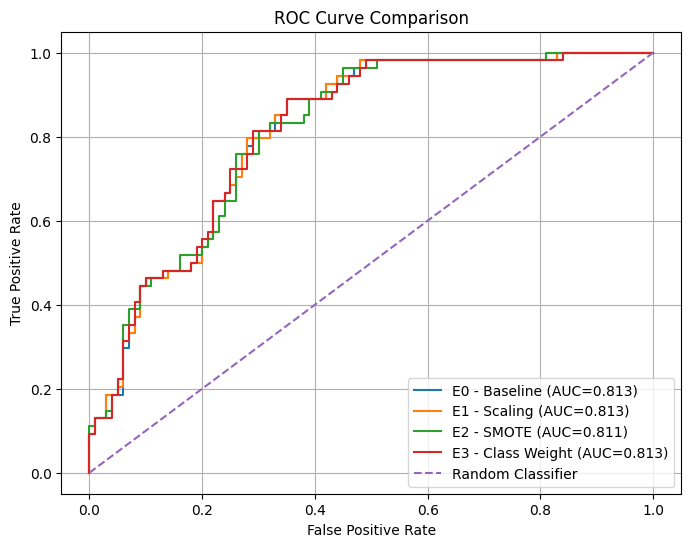

In [61]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_e0, tpr_e0, _ = roc_curve(y_test, y_prob_e0)
fpr_e1, tpr_e1, _ = roc_curve(y_test, y_prob_e1)
fpr_e2, tpr_e2, _ = roc_curve(y_test, y_prob_e2)
fpr_e3, tpr_e3, _ = roc_curve(y_test, y_prob_e3)

plt.figure(figsize=(8, 6))

plt.plot(fpr_e0, tpr_e0, label=f"E0 - Baseline (AUC={roc_auc_e0:.3f})")
plt.plot(fpr_e1, tpr_e1, label=f"E1 - Scaling (AUC={roc_auc_e1:.3f})")
plt.plot(fpr_e2, tpr_e2, label=f"E2 - SMOTE (AUC={roc_auc_e2:.3f})")
plt.plot(fpr_e3, tpr_e3, label=f"E3 - Class Weight (AUC={roc_auc_e3:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

### Precision-Recall Curves

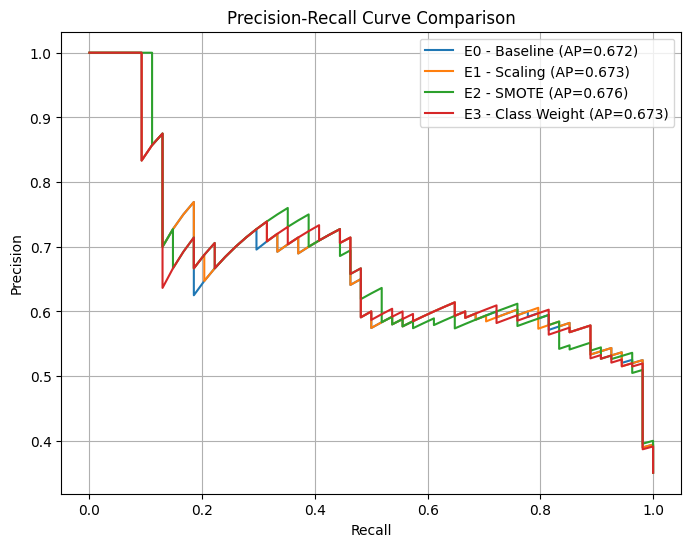

In [62]:
from sklearn.metrics import precision_recall_curve

precision_e0, recall_e0, _ = precision_recall_curve(y_test, y_prob_e0)
precision_e1, recall_e1, _ = precision_recall_curve(y_test, y_prob_e1)
precision_e2, recall_e2, _ = precision_recall_curve(y_test, y_prob_e2)
precision_e3, recall_e3, _ = precision_recall_curve(y_test, y_prob_e3)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_e0,
    precision_e0,
    label=f"E0 - Baseline (AP={pr_auc_e0:.3f})"
)

plt.plot(
    recall_e1,
    precision_e1,
    label=f"E1 - Scaling (AP={pr_auc_e1:.3f})"
)

plt.plot(
    recall_e2,
    precision_e2,
    label=f"E2 - SMOTE (AP={pr_auc_e2:.3f})"
)

plt.plot(
    recall_e3,
    precision_e3,
    label=f"E3 - Class Weight (AP={pr_auc_e3:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

###Advanced Evaluation

The advanced evaluation examines model performance beyond the default
classification threshold of 0.50.

ROC-AUC was used to evaluate the ability of each model to distinguish
between diabetic and non-diabetic cases across different thresholds.
Precision-Recall AUC (Average Precision) was also calculated because
diabetic cases represent the minority class and positive-class performance
is particularly important.

Prediction probabilities were generated for all four preprocessing
experiments. These probabilities were then used to evaluate the effect
of different classification thresholds on the leading E3 configuration.

The threshold analysis demonstrates that classification performance is
not fixed at a single threshold. Lower thresholds generally increase
diabetic recall but can also increase false positives, while higher
thresholds may improve precision at the cost of missing more diabetic
cases.

E3  Class Weight remains the leading configuration based on the earlier
evaluation, particularly because it achieved the highest diabetic recall
and F1 score among the tested configurations.

However, threshold selection should not be considered clinically
validated. The current analysis is a controlled machine-learning
benchmark using a single fixed train-test split. Additional validation,
including stratified cross-validation and independent external testing,
would be required before making claims about clinical deployment.

### Final Advanced Evaluation Conclusion

The advanced evaluation shows that the preprocessing strategies have only
small effects on overall model discrimination. ROC-AUC values remain very
similar across all experiments, ranging from approximately 0.811 to 0.813.
This indicates that the different preprocessing choices do not substantially
change the model's ability to rank diabetic cases above non-diabetic cases.

PR-AUC shows a similar pattern. E2  SMOTE achieves the highest PR-AUC of
0.6758, but the improvement over the other configurations is relatively
small.

In contrast, threshold-dependent evaluation reveals a more substantial
difference. E3  Class Weight provides strong diabetic-case detection at
the default threshold, achieving 70.37% recall and 64.96% F1.

Changing the E3 classification threshold demonstrates the precision-recall
trade-off. At a threshold of 0.30, diabetic recall increases to 88.89%,
while precision decreases to 54.55%. At a threshold of 0.40, recall remains
high at 83.33% and F1 reaches 67.67% among the tested thresholds.

These results demonstrate that preprocessing choices and classification
thresholds affect model behavior differently. Preprocessing can influence
the model's treatment of class imbalance, while threshold selection directly
controls the trade-off between detecting positive cases and generating
false positives.

For the current benchmark, E3  Class Weight remains the preferred
configuration because it provides the strongest balance of accuracy,
diabetic recall, and F1 at the default threshold.

The threshold results should not be interpreted as clinical validation.
The evaluation is based on a single fixed test set, and additional
validation such as stratified cross-validation and independent external
testing would be required before considering the model for real-world
clinical use.

# 7. Clinical Interpretation & Feature Analysis

This section examines the clinical variables that contribute most strongly
to the model's predictions.

Feature importance is analyzed using the E3  Class Weight configuration,
which achieved the strongest overall performance in the controlled
preprocessing experiment.

The purpose of this analysis is not to establish medical causation.
Instead, it provides model-level evidence about which variables contribute
most to the predictions made by the machine-learning model.

Feature importance should therefore be interpreted as predictive
importance rather than clinical causality.

### Extract Feature Coefficients

### 6.7 Logistic Regression Coefficient Interpretation

Because **E3 uses Logistic Regression**, we can interpret its coefficients to understand how each feature influences the prediction.

The pipeline contains:

```text
Imputer → StandardScaler → LogisticRegression

In [63]:
# Extract the trained Logistic Regression model from E3

e3_model = e3_pipeline.named_steps["model"]

feature_names = X_train.columns

coefficients = e3_model.coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficient_df

,Feature,Coefficient,Absolute_Coefficient
1,Glucose,1.183483,1.183483
5,BMI,0.709592,0.709592
0,Pregnancies,0.372902,0.372902
6,DiabetesPedigreeFunction,0.287734,0.287734
7,Age,0.186434,0.186434
4,Insulin,-0.044609,0.044609
2,BloodPressure,-0.014612,0.014612
3,SkinThickness,0.013980,0.013980


### Understand the Coefficients

Logistic Regression coefficients show how each feature affects the prediction.

### Interpretation

- **Positive coefficient:** Increases the likelihood of diabetes.
- **Negative coefficient:** Decreases the likelihood of diabetes.
- **Larger absolute value:** Stronger influence on the prediction.

Since E3 uses `StandardScaler`, we can compare the relative importance of the features more easily.

###Visualize Feature Influence

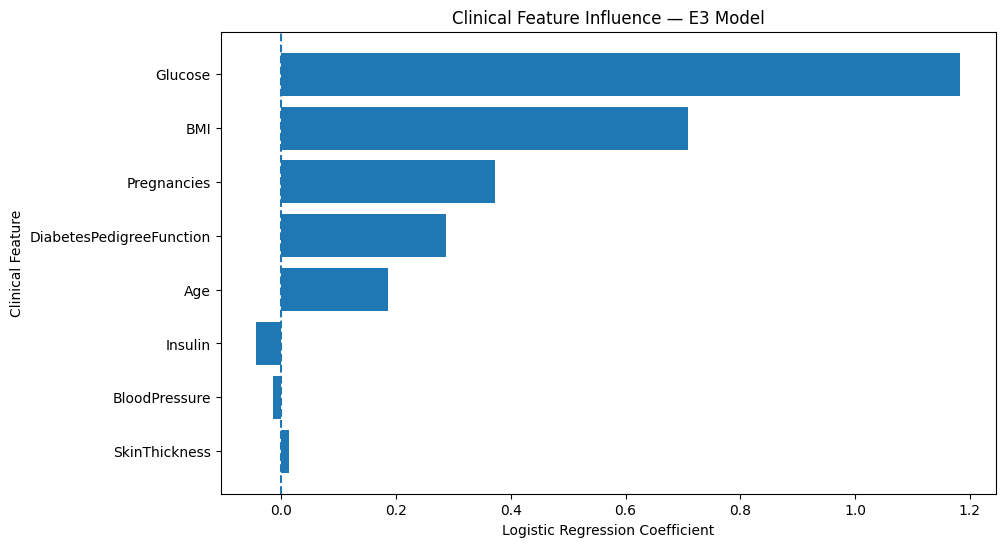

In [64]:
plt.figure(figsize=(10, 6))

plt.barh(
    coefficient_df["Feature"],
    coefficient_df["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Clinical Feature")
plt.title("Clinical Feature Influence — E3 Model")

plt.gca().invert_yaxis()

plt.show()

### How to Read the Graph

- **Right of zero:** Positive coefficients
- **Left of zero:** Negative coefficients
- **Farther from zero:** Stronger contribution to the prediction

### Rank Features by Absolute Influence

In [65]:
feature_importance_df = coefficient_df[
    ["Feature", "Coefficient", "Absolute_Coefficient"]
].copy()

feature_importance_df

,Feature,Coefficient,Absolute_Coefficient
1,Glucose,1.183483,1.183483
5,BMI,0.709592,0.709592
0,Pregnancies,0.372902,0.372902
6,DiabetesPedigreeFunction,0.287734,0.287734
7,Age,0.186434,0.186434
4,Insulin,-0.044609,0.044609
2,BloodPressure,-0.014612,0.014612
3,SkinThickness,0.013980,0.013980


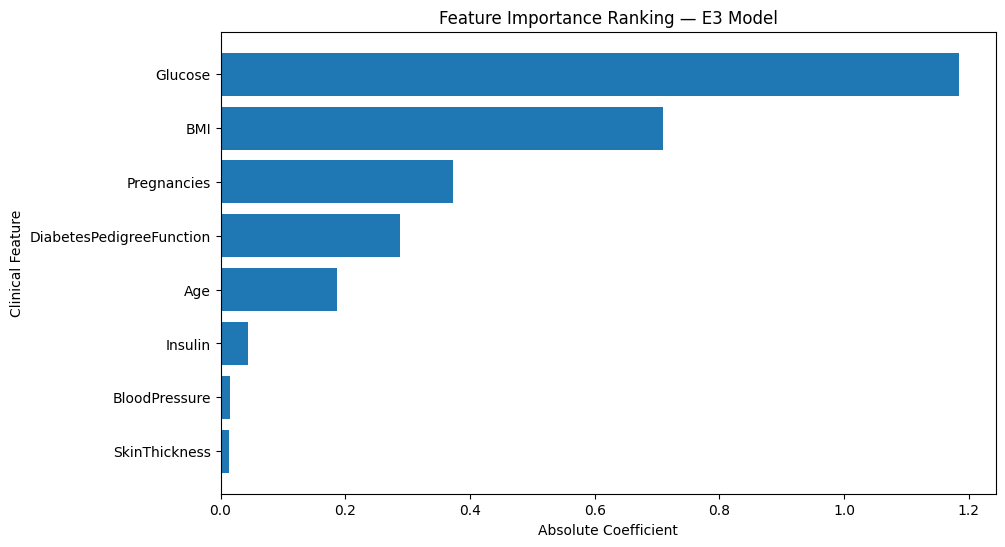

In [66]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Absolute_Coefficient"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Clinical Feature")
plt.title("Feature Importance Ranking — E3 Model")

plt.gca().invert_yaxis()

plt.show()

### Top Clinical Features

In [67]:
top_features = feature_importance_df.head(3)

print("Top 3 features based on absolute Logistic Regression coefficients:")
print(top_features)

Top 3 features based on absolute Logistic Regression coefficients:
       Feature  Coefficient  Absolute_Coefficient
1      Glucose     1.183483              1.183483
5          BMI     0.709592              0.709592
0  Pregnancies     0.372902              0.372902


### Clinical Interpretation

The feature analysis identifies the variables that contribute most strongly
to the Logistic Regression model's predictions.

A positive coefficient indicates that higher values of the corresponding
feature increase the model's predicted tendency toward the diabetic class,
while a negative coefficient indicates the opposite direction.

Because the predictors were standardized before model training, the
coefficient magnitudes can be compared more meaningfully across features.

The most influential variables should be interpreted as predictive
features rather than direct causes of diabetes. A machine-learning model
can identify statistical patterns without establishing biological or
clinical causation.

In particular, the importance of a feature does not mean that changing that
feature alone would necessarily change a patient's diabetes status.

This distinction is important when interpreting machine-learning models
using clinical datasets.

 | Feature | Clinical Interpretation |
|---|---|
| Glucose | Strong indicator of blood glucose level and commonly highly predictive of diabetes |
| BMI | Represents body mass relative to height and can provide useful predictive information |
| Age | Captures age-related variation in diabetes risk |
| DiabetesPedigreeFunction | Represents a measure related to family-history/genetic risk |
| BloodPressure | Provides additional metabolic and cardiovascular information |
| Pregnancies | Can contribute predictive information related to pregnancy history |
| SkinThickness | Provides an indirect measure related to body composition |
| Insulin | Provides information related to insulin response/metabolism |

### Limitations of Feature Interpretation

Several limitations should be considered when interpreting the feature
importance results.

1. Logistic Regression coefficients represent model associations rather
   than causal relationships.

2. Correlated clinical variables can share predictive information, meaning
   the importance of one feature may be affected by the presence of another.

3. Feature importance is specific to the trained model and dataset and may
   change with different samples, preprocessing strategies, or algorithms.

4. The analysis is based on a single train-test split and therefore may not
   fully represent the variability expected on unseen populations.

5. The Pima Indians Diabetes dataset is a benchmark dataset and should not
   automatically be treated as representative of every clinical population.

6. Feature importance alone cannot determine whether a variable is
   clinically actionable or appropriate for medical decision-making.

7. Additional methods such as permutation importance or SHAP analysis could
   provide complementary explanations of model behavior.

### Clinical Interpretation Summary

The feature analysis provides insight into which clinical variables are
most influential in the E3 Logistic Regression model.

The analysis complements the earlier performance evaluation by connecting
model predictions with the underlying clinical variables.

The results should be interpreted as evidence of predictive patterns rather
than causal medical relationships. Features with larger coefficient
magnitudes have greater influence on the model's predictions within this
specific dataset and preprocessing configuration.

The combination of performance evaluation and feature interpretation
provides a more complete understanding of the model. Performance metrics
indicate how well the model predicts diabetes, while feature analysis helps
explain which variables contribute to those predictions.

However, the model remains an experimental machine-learning benchmark.
External validation, cross-validation, calibration, and clinical validation
would be required before considering the approach for real-world medical
decision support.

#Step 8  Final Documentation & Conclusion

### Final Documentation & Conclusion

This section consolidates the experimental findings and identifies the
most appropriate preprocessing configuration for the Pima Indians Diabetes
classification task.

Four controlled experiments were evaluated using the same Logistic
Regression classifier, identical train-test split, and consistent
evaluation metrics. Only the preprocessing and class-imbalance strategy
was changed between experiments.

The objective was to understand how preprocessing decisions affect
downstream model performance, particularly the detection of diabetic cases.

###  Final Performance Comparison

| Experiment | Preprocessing | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---|---:|---:|---:|---:|---:|---:|
| E0 | Median Imputation | 70.13% | 58.70% | 50.00% | 54.00% | 0.8130 | 0.6723 |
| E1 | Imputation + Scaling | 70.78% | 60.00% | 50.00% | 54.55% | 0.8130 | 0.6733 |
| E2 | Imputation + Scaling + SMOTE | 70.78% | 57.38% | 64.81% | 60.87% | 0.8113 | 0.6758 |
| E3 | Imputation + Scaling + Class Weight | **73.38%** | **60.32%** | **70.37%** | **64.96%** | 0.8126 | 0.6727 |

### Selected Configuration

Based on the controlled experimental results, E3  Class Weight is selected
as the leading preprocessing configuration.

E3 achieved:

- Accuracy: 73.38%
- Diabetic Precision: 60.32%
- Diabetic Recall: 70.37%
- Diabetic F1: 64.96%
- ROC-AUC: 0.8126
- PR-AUC: 0.6727

The strongest reason for selecting E3 is its performance on diabetic-case
detection. It identifies 38 of the 54 diabetic cases in the test set,
compared with 27 cases detected by the baseline.

Therefore, E3 reduces false negatives from 27 to 16 and improves diabetic
recall by 20.37 percentage points compared with the baseline.

### Effect of Preprocessing Decisions

### Median Imputation

Replacing clinically implausible zero values with missing values followed
by median imputation provides a consistent strategy for handling missing
information.

Median imputation is relatively robust to extreme observations and avoids
removing a substantial number of samples from the dataset.

### Standard Scaling

Standard scaling produced only a small improvement when used alone.

E0 achieved 70.13% accuracy and 50.00% diabetic recall, while E1 achieved
70.78% accuracy and the same 50.00% recall.

This indicates that scaling alone did not substantially improve diabetic
case detection in this experiment.

### SMOTE

SMOTE substantially improved diabetic recall.

Recall increased from 50.00% in E0 to 64.81% in E2. However, this was
accompanied by an increase in false positives and a reduction in precision.

SMOTE therefore demonstrates the expected trade-off between detecting more
minority-class cases and generating additional positive predictions.

### Class Weighting

Class weighting produced the strongest overall result.

E3 achieved the highest accuracy, diabetic recall, and F1 score among the
four experiments.

It reduced false negatives from 27 to 16 and increased diabetic recall from
50.00% to 70.37%.

This demonstrates that class weighting was more effective than SMOTE for
this particular dataset and Logistic Regression configuration.

### Threshold Analysis Conclusion

The threshold experiment demonstrated that the default probability
threshold of 0.50 is not the only possible operating point.

For E3:

| Threshold | Precision | Recall | F1 |
|---:|---:|---:|---:|
| 0.30 | 54.55% | **88.89%** | 67.61% |
| 0.40 | 56.96% | 83.33% | **67.67%** |
| 0.50 | 60.32% | 70.37% | 64.96% |
| 0.60 | 59.62% | 57.41% | 58.49% |

Lowering the threshold increases diabetic recall but also decreases
precision.

The threshold of 0.40 produced the highest F1 score among the tested
thresholds, while the threshold of 0.30 produced the highest recall.

These thresholds are experimental operating points rather than clinically
validated thresholds. Threshold selection for real-world medical
applications would require additional validation and domain-specific
cost-benefit analysis.

### Key Findings

1. The original dataset contains 768 observations and 8 predictor
   variables.

2. Several variables contain clinically implausible zero values. These
   values were treated as missing for Glucose, BloodPressure,
   SkinThickness, Insulin, and BMI.

3. The dataset contains moderate class imbalance, with 500 non-diabetic
   and 268 diabetic observations.

4. Standard scaling alone produced only a minor performance change.

5. SMOTE increased diabetic recall substantially but also increased false
   positives.

6. Class weighting provided the strongest overall balance of accuracy,
   recall, and F1.

7. E3 reduced false negatives from 27 to 16 compared with the baseline.

8. Diabetic recall improved from 50.00% to 70.37%, representing a
   20.37-percentage-point improvement.

9. ROC-AUC remained approximately 0.81 across all experiments, indicating
   that preprocessing choices had limited effect on overall ranking
   discrimination.

10. Threshold analysis demonstrated that model performance can change
    considerably depending on the selected classification threshold.

11. The results show that preprocessing decisions should be evaluated
    according to the specific objective rather than accuracy alone.

### Limitations

This study has several limitations.

### 1. Single Dataset

The analysis uses the Pima Indians Diabetes Dataset. Results may not
generalize to other populations or healthcare settings.

### 2. Single Train-Test Split

The main comparison uses one fixed 80/20 stratified train-test split.
Different splits could produce somewhat different results.

### 3. Limited Model Selection

The experiments use Logistic Regression as the common classifier. Other
algorithms may respond differently to the preprocessing strategies.

### 4. Limited Hyperparameter Tuning

The models were evaluated using a controlled configuration rather than
extensive hyperparameter optimization.

### 5. Missing-Value Assumptions

Zero values were treated as missing for selected clinical variables based
on domain plausibility. Different missing-data strategies could produce
different results.

### 6. No External Validation

The model was not evaluated on an independent external clinical dataset.

### 7. No Clinical Validation

The results represent a machine-learning benchmark and should not be
interpreted as evidence that the model is suitable for clinical diagnosis
or medical decision-making.

### 8. Threshold Selection

The tested thresholds were evaluated on the same held-out test set.
Therefore, selecting a threshold based on these results can introduce
optimistic bias if the same test set is repeatedly used for model
selection.

### Final Project Conclusion

This project evaluated how different preprocessing and class-imbalance
strategies affect Logistic Regression performance on the Pima Indians
Diabetes Dataset.

Four controlled experiments were performed using a consistent train-test
split and evaluation framework. The experiments compared median
imputation, standard scaling, SMOTE-based oversampling, and class
weighting.

The results demonstrate that preprocessing decisions can significantly
affect minority-class performance even when overall ROC-AUC remains
relatively stable.

Standard scaling alone produced only a small improvement over the baseline.
SMOTE substantially improved diabetic recall from 50.00% to 64.81%, but
also increased false positives.

Class weighting produced the strongest overall configuration. E3 achieved
73.38% accuracy, 70.37% diabetic recall, and a 64.96% diabetic F1 score.
It also reduced false negatives from 27 to 16 compared with the baseline.

The advanced evaluation showed that ROC-AUC remained close to 0.81 across
all experiments. This suggests that the preprocessing strategies did not
dramatically change the model's overall discrimination ability. However,
they changed the model's decision behavior and its ability to detect
minority-class cases.

Threshold analysis further demonstrated that classification performance
depends on the selected probability threshold. Lower thresholds can
increase diabetic recall, while higher thresholds generally favor
precision.

Overall, the experiment demonstrates an important machine-learning
principle: the best preprocessing strategy depends on the objective of
the model. In a clinical classification setting, accuracy alone may not
be sufficient, and metrics such as recall, F1, false-negative rate, and
precision-recall performance can provide more meaningful information.

E3  Class Weight is therefore selected as the leading configuration for
this experimental study. However, the model remains a benchmark rather
than a clinically deployable system. Stratified cross-validation,
independent external validation, calibration analysis, and clinical
evaluation would be required before considering real-world deployment.

### Final Summary

**Best Configuration:** E3  Class Weight

**Classifier:** Logistic Regression

**Accuracy:** 73.38%

**Diabetic Precision:** 60.32%

**Diabetic Recall:** 70.37%

**Diabetic F1:** 64.96%

**ROC-AUC:** 0.8126

**PR-AUC:** 0.6727

**False Negatives:** 16

**False-Negative Rate:** 29.63%

**Baseline False Negatives:** 27

**Recall Improvement:** +20.37 percentage points

### Main Insight

The experiment demonstrates that class-imbalance handling can have a
greater effect on minority-class detection than scaling alone. Although
ROC-AUC remained stable across experiments, class weighting substantially
improved diabetic recall and reduced false negatives.

The final model should be considered an experimental benchmark and not a
clinically validated diagnostic system.